In [38]:
import sys
import os

from instant_aiv.models.NNpp import *
from instant_aiv.models.metrics import *
from instant_aiv.manage.plots import *
from instant_aiv.manage.dataloader import *


# Libraries
import argparse
import numpy as np
import scipy.io
import time
import gc
import pandas as pd
from functools import reduce
import pickle


#Plots
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec


import os
import numpy as np
import jax
from jax import jit, grad, vmap, value_and_grad,jvp

import jax.numpy as jnp
import optax

from typing import Tuple
import time


import h5py
from typing import List, Dict
from pyDOE import lhs
import tqdm
import scipy.integrate as integrate
from sklearn.model_selection import train_test_split
from matplotlib.ticker import FormatStrFormatter


In [39]:
cmap = 'plasma'
num_colors=8
# Create a colormap
cmap = plt.get_cmap(cmap)
colors = [cmap(i) for i in np.linspace(0, 1, num_colors)]
colors=colors[:num_colors//4]+colors[3*num_colors//4:]
print(len(colors))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['font.size'] = 20

4


# Tunning Parameters

In [40]:
parser = argparse.ArgumentParser(description='Tunning_parameters')
parser.add_argument('--run_type'   , type=str  , default='Real_M1')
parser.add_argument('--mode'       , type=str  , default='PINN')
parser.add_argument('--Run_MODE'   , type=str  , default='Plots')

parser.add_argument('--num_layer'  , type=int  , default=8)
parser.add_argument('--width_layer', type=int  , default=200)
parser.add_argument('--train_ratio' , type=float, default=0.5)
parser.add_argument('--Weight_Norm'    , type=int , default=1)
parser.add_argument('--Mod_MLP'    , type=int , default=0)
parser.add_argument('--Use_ResNet'    , type=int , default=1)
parser.add_argument('--Adaptive'    , type=int , default=1)
parser.add_argument('--Light'    , type=int , default=0)
parser.add_argument('--offset_k' , type=float  , default=1.0)

parser.add_argument('--batch_size' , type=int  , default=10000)
parser.add_argument('--num_gsteps' , type=int  , default=400*(10**3))
parser.add_argument('--Name' , type=str  , default='Mouse_1')
parser.add_argument('--normalization' , type=str  , default='chebyshev5')
parser.add_argument('--Equal_Batch' , type=bool  , default=True)
parser.add_argument('--optimizer' , type=str  , default='AdamW')

parser.add_argument('--use_RBA'    , type=int , default=1)
parser.add_argument('--k_samp' , type=float  , default=2.0)
parser.add_argument('--c_samp' , type=float  , default=0.5)
parser.add_argument('--lr_lambdas_0' , type=float  , default=0.1)
parser.add_argument('--gamma' , type=float  , default=0.999)


parser.add_argument('--use_mass'    , type=int , default=1)



args, unknown = parser.parse_known_args()
for arg, value in vars(args).items():
    print(f'{arg}: {value}')

run_type: Real_M1
mode: PINN
Run_MODE: Plots
num_layer: 8
width_layer: 200
train_ratio: 0.5
Weight_Norm: 1
Mod_MLP: 0
Use_ResNet: 1
Adaptive: 1
Light: 0
offset_k: 1.0
batch_size: 10000
num_gsteps: 400000
Name: Mouse_1
normalization: chebyshev5
Equal_Batch: True
optimizer: AdamW
use_RBA: 1
k_samp: 2.0
c_samp: 0.5
lr_lambdas_0: 0.1
gamma: 0.999
use_mass: 1


In [41]:
Run_type = args.run_type
Mode=args.mode
#ResNet Architecures
Use_ResNet=args.Use_ResNet 
Adaptive=args.Adaptive 
Light=args.Light 
num_layer=args.num_layer
use_mass=args.use_mass 
offset_k=args.offset_k 
args.Name=args.Name+str(offset_k)

if Use_ResNet:
    num_layer=int((num_layer+2)/2)

width_layer=args.width_layer
layers={
    'P' :[4]  + num_layer*[3*width_layer//4] + [1],
    'c' :[4]  + num_layer*[width_layer] + [1],
    'c_std' :[4]  + num_layer*[width_layer//3] + [1],
    'k' :[4]  + num_layer*[3*width_layer//4] + [1],
    'D' :[4]  + num_layer*[3*width_layer//4] + [1],
}
layers_ref=np.copy(layers['P'])
layers_1=np.copy(layers['P'])

train_ratio=args.train_ratio

Details=f'{args.Name}-Train:{train_ratio}_mass:{args.use_mass}'

Run_MODE=args.Run_MODE

print('Model Architecture:')
print(layers)

activation = 'sin'
initialization = 'xavier'
normalization  = args.normalization
loss_metric ='L2'
Weight_Norm =args.Weight_Norm#Weight Normalization
use_RBA=args.use_RBA
Mod_MLP=args.Mod_MLP  #Modified MLP
normalize_outputs=False
init_zero=True
Adaptive_AF=False

#Optimization
num_gsteps  = args.num_gsteps
batch_size = args.batch_size

#learning 
lam_min=0.0
lr0=2*10**(-3)
lrf=5*10**(-5)
lr_lambdas_0=args.lr_lambdas_0
gamma=args.gamma
max_lambda=lr_lambdas_0/(1-gamma)
print(f'Max lambdas will be:{max_lambda}')
T_e=num_gsteps
decay_rate=0.9
decay_step=0
seed_np=1234
key = jax.random.PRNGKey(seed_np)
key, subkey = jax.random.split(key)

#Scaling factor
p_scale=1

#Sample Points
N_r=1000000
N_d=1000000
# Model
dataset_name = f'{Details}'


Model Architecture:
{'P': [4, 150, 150, 150, 150, 150, 1], 'c': [4, 200, 200, 200, 200, 200, 1], 'c_std': [4, 66, 66, 66, 66, 66, 1], 'k': [4, 150, 150, 150, 150, 150, 1], 'D': [4, 150, 150, 150, 150, 150, 1]}
Max lambdas will be:99.99999999999991


In [42]:
project_root = find_package_directory() # if error please define the root package directly (e.g. project_root='/users/.../' )
data_path=project_root+'/Data/Real_Data/M1/M1_concentration.mat'
path_vels=project_root+"/Data/Real_Data/M1/Front_Tracking.mat"
save_path=project_root+f'/Results/{Run_type}/'
big_data_path=save_path
print(f'Analizing:{data_path}')
print(f'Details:{Details}')
print(f'dataset_name:{dataset_name}')


Analizing:/oscar/data/gk/jdtoscan/References/MR-AVI//Data/Real_Data/M1/M1_concentration.mat
Details:Mouse_11.0-Train:0.5_mass:1
dataset_name:Mouse_11.0-Train:0.5_mass:1


In [43]:
use_RBA=int(use_RBA)
print(f'Using RBA:{use_RBA}')

Using RBA:1


## Settings


In [44]:
# Fetching activation function
activation_fn = ACTIVATION_FUNCTIONS.get(activation.lower())

# Fetching normalization functions and metrics
norm_settings = NORMALIZATION_FUNCTIONS.get(normalization.lower())
norm_fn = norm_settings['fn']
Norm_metric1 = norm_settings['metric1']
Norm_metric2 = norm_settings['metric2']

# Fetching error function
Error_fn = ERROR_FUNCTIONS.get(loss_metric.lower())

#Adjust layer structure to account for Chebyshev Feature Embbeding
for key in layers.keys():
    embed_size=layers[key][1]
    input_dim=layers[key][0]*5
    output_dim=layers[key][-1]
    layers[key]=[input_dim]+(num_layer)*[embed_size]+ [output_dim]
print(f'New architecture:{layers}')

New architecture:{'P': [20, 150, 150, 150, 150, 150, 1], 'c': [20, 200, 200, 200, 200, 200, 1], 'c_std': [20, 66, 66, 66, 66, 66, 1], 'k': [20, 150, 150, 150, 150, 150, 1], 'D': [20, 150, 150, 150, 150, 150, 1]}


In [45]:
np.random.seed(seed_np)
params= init_params_dict(layers, initialization,Use_ResNet)

# Model selection
pinn_fn =select_model(WN=Weight_Norm,Use_ResNet=Use_ResNet,Adaptive=Adaptive,Light=Light)
print(f'The model will be: {pinn_fn}')

You selected: Network mlp with degree(if KAN) 5, initialization xavier,Use_ResNet 1
The model will be: <function WN_ResNet_adaptive at 0x7f7f4a3bdc10>


# Load Network hyperparameters

In [46]:
save_file_details=project_root+'/Results/Initialization_Details_Real.pkl'

with open(save_file_details, 'rb') as f:
    file_details_loaded = pickle.load(f)
print(file_details_loaded.keys())
M1_all=file_details_loaded['M1']
M2_all=file_details_loaded['M2']
lb_all=file_details_loaded['lb_all']
ub_all=file_details_loaded['ub_all']
off_set=file_details_loaded['off_set']
layers_k=file_details_loaded['layers']
offset_k=file_details_loaded['offset_k']
k_params_file=project_root+file_details_loaded['path']
dataset_k=file_details_loaded['name']
p_scale=file_details_loaded['p_scale']
Norm_fn={}
Norm_fn['c']=norm_fn
Norm_fn['P']=norm_fn

Norm_fn['k']=Encode_Chebysev_5


k_char0=file_details_loaded['k_char0']
P_char=3.938900070900201
loaded_params_k = load_params_dict(k_params_file, dataset_k, layers_k, initialization,type='Final',Use_ResNet=Use_ResNet) 
print('Parameters loaded from file')
params['k']=loaded_params_k['k']
layers['k']=layers_k['k']
params['c']=loaded_params_k['c']
layers['c']=layers_k['c']
params['P']=loaded_params_k['P']
layers['P']=layers_k['P']
params['c_std']=loaded_params_k['c_std']
layers['c_std']=layers_k['c_std']

dict_keys(['path', 'name', 'layers', 'lb_all', 'ub_all', 'off_set', 'k_char0', 'offset_k', 'p_scale', 'M1', 'M2'])


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 22.97it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 27.53it/s]


...

Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 50.24it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 32.50it/s]


Initializing:mlp parameters.
Parameters loaded from file


## Create Folders

In [47]:
subdirs = ["General","Imgs", "Big_Data", "Data", "Flow_rate", "Errors",'System_video','System_video_abs','System_video_scaled','System_video_crop','PDF','PDF_filtered']
paths = create_and_return_directories(save_path, dataset_name, subdirs)
print(dataset_name)
result_path = paths["General"]
images_path = paths["Imgs"]
big_path = paths["Big_Data"]
Video_path = paths["Flow_rate"]
Pdf_path = paths["PDF"]
System_video_path = paths["System_video"]
System_video_abs_path = paths["System_video_abs"]
System_video_crop_path = paths["System_video_crop"]
System_video_scaled_path = paths["System_video_scaled"]
errors_path = paths["Errors"]


The general path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/General/
The imgs path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/Imgs/
The big data path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/Big_Data/


The data path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/Data/
The flow rate path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/Flow_rate/
The errors path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/Errors/
The system video path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/System_video/
The system video abs path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/System_video_abs/
The system video scaled path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/System_video_scaled/
The system video crop path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/System_video_crop/
The pdf path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Real_M1/Mouse_11.0-Train:0.5_mass:1/PDF/
The 

# Non-Dimensional values

In [48]:
nu_e=7*10**(-7)
rho=993
mu=0.6913e-3
h=0.00034 #Maximum length by 100
L_char=h
U_char=0.5/5#mm/min
D_char=2.4e-10#m2/s
U_char=U_char*(1/1000)*(1/60)#m/s
T_char=L_char/U_char
C_char=1
Pef=U_char*L_char/D_char
mms=10**6
L_char=L_char
k_char=k_char0
P_char=U_char*L_char*mu/k_char
print(T_char,L_char,U_char,C_char,D_char)
print(Pef)
print(k_char)
print(P_char)

T_SI=1
L_SI=1000
D_SI=1#10**6
U_SI=1#1000
P_SI=1
K_SI=1#10**6
SI_fact_steady=np.array([1/T_SI,1/L_SI,1/L_SI,1/L_SI,1/D_SI,1/U_SI,1/U_SI,1/U_SI,1/P_SI,1/K_SI])
SI_fact=np.array([1/T_SI,1/L_SI,1/L_SI,1/L_SI,1])
non_dim_fact_steady=np.array([1/T_char,1/L_char,1/L_char,1/L_char,1/D_char,1/U_char,1/U_char,1/U_char,1/P_char,1/k_char])
non_dim_fact=np.array([1/T_char,1/L_char,1/L_char,1/L_char,1])
print(non_dim_fact)

204.00000000000003 0.00034 1.6666666666666667e-06 1 2.4e-10
2.361111111111111
1e-14
39.17366666666667
[4.90196078e-03 2.94117647e+03 2.94117647e+03 2.94117647e+03
 1.00000000e+00]


## Load Data


In [49]:
Data = scipy.io.loadmat(data_path)
X_nnf = Data['Data']
#Arrays
T_star=X_nnf[:,:,0]
X_star=X_nnf[:,:,1]
Y_star=X_nnf[:,:,2]
Z_star=X_nnf[:,:,3]
C_star=X_nnf[:,:,4]
Data = scipy.io.loadmat(data_path)
X_nnf = Data['Data']
Xnn=np.concatenate(X_nnf)
Data['Data_labels']
X_data_raw=Xnn
X_res=Xnn[:,0:4]
Pef=Xnn[0,6]
Re=Xnn[0,7]
Da=Xnn[0,8]
print(Pef,Re,Da)

2.5180253917871505 0.0008095238095238096 8.650519031141868e-06


In [50]:
T_star=X_nnf[:,:,0]
X_star=X_nnf[:,:,1]
Y_star=X_nnf[:,:,2]
Z_star=X_nnf[:,:,3]
C_star=X_nnf[:,:,4]

## Front Tracking

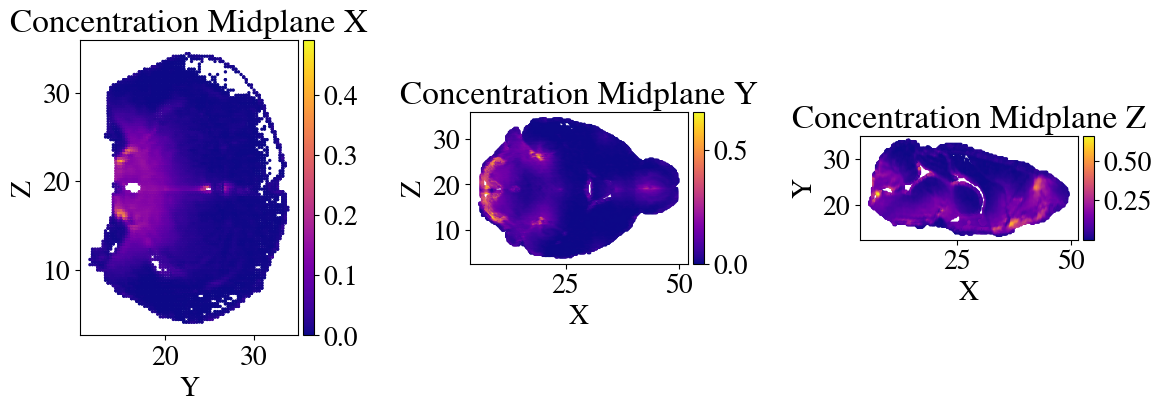

In [51]:
frame=30
X_plot = X_nnf[30]
t,x, y, z, c = X_plot[:,0], X_plot[:,1], X_plot[:,2], X_plot[:,3], X_plot[:,4]
# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

tolerance = 0.5  # Adjust based on your dataset's spread

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# Prepare for visualization

# Variables for plotting
variables = [c]  # Use the scalar field for coloring
variable_names = ['Concentration']

# Visualization
for i, var in enumerate(variables):
    fig = plt.figure(figsize=(12, 8))  # Adjust size as needed

    for j in range(3):
        ax = fig.add_subplot(1, 3, j + 1)
        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x, scatter_y = y[filter_mask], z[filter_mask]
            xlabel, ylabel = 'Y', 'Z'
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x, scatter_y = x[filter_mask], z[filter_mask]
            xlabel, ylabel = 'X', 'Z'
        else:  # j == 2
            filter_mask = z_midplane_filter
            scatter_x, scatter_y = x[filter_mask], y[filter_mask]
            xlabel, ylabel = 'X', 'Y'

        # Use the scalar field for coloring
        scatter = ax.scatter(scatter_x, scatter_y, c=var[filter_mask], cmap=cmap, s=2)
        ax.set_title(f'{variable_names[i]} Midplane {["X", "Y", "Z"][j]}')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.axis('equal')
        ax.axis('on')  # Change to 'off' if you prefer no axis

        # Adding a colorbar to each subplot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)

plt.tight_layout()
plt.show()


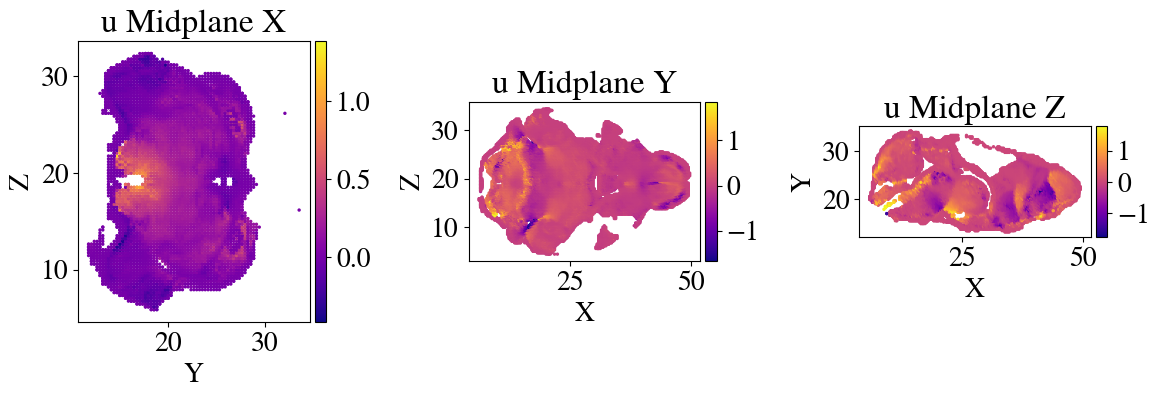

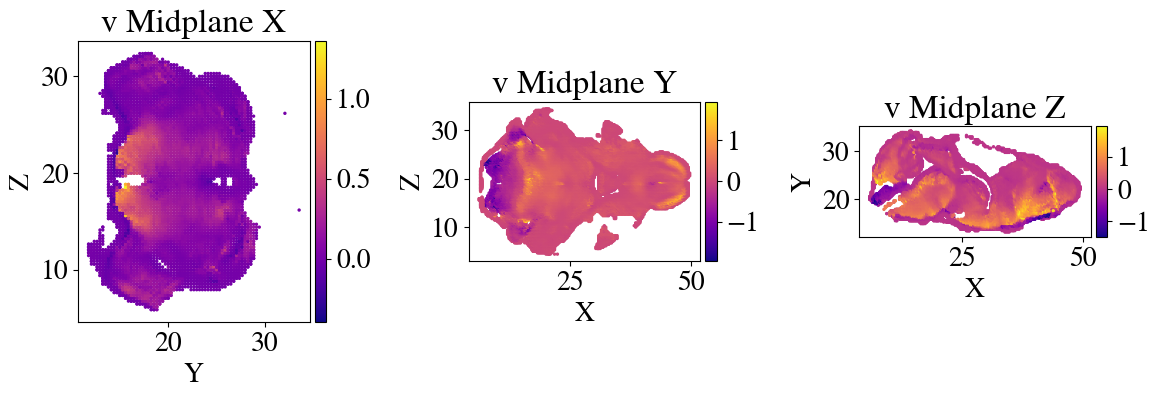

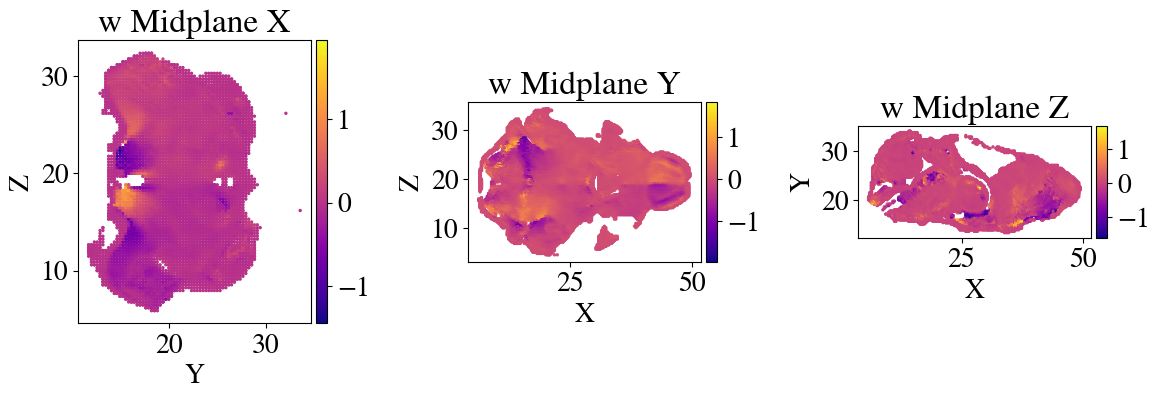

In [52]:
front_track_raw=scipy.io.loadmat(path_vels)
X_val=front_track_raw['mat_v']
fact_vel=(1/60)*(1/1000)*(1/U_char)
fact_L=(1/1000)*(1/L_char)
nond_fact=np.array([fact_L,fact_L,fact_L,fact_vel,fact_vel,fact_vel])
X_val=X_val*nond_fact
X_init_clean = X_val[~np.isnan(X_val).any(axis=1)]
X_init_clean=np.hstack((X_init_clean[:,0:1]*0+10,X_init_clean))
# Assuming X_val is loaded and contains [x, y, z, u, v, w] as columns
x, y, z, u, v, w = [X_val[:, i] for i in range(6)]

# Calculate global min and max for velocity components for normalization
global_min = np.min(X_val[:, 3:], axis=0)
global_max = np.max(X_val[:, 3:], axis=0)

# Prepare for visualization
# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

tolerance = 0.5  # Adjust based on your dataset's spread

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# Variables for plotting
variables = [u, v, w]  # Adjust if you're interested in other variables
variable_names = ['u', 'v', 'w']

# Visualization
for i, var in enumerate(variables):
    fig = plt.figure(figsize=(12, 8))  # Adjust size as needed

    for j in range(3):
        ax = fig.add_subplot(1, 3, j + 1)
        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x, scatter_y = y[filter_mask], z[filter_mask]
            xlabel, ylabel = 'Y', 'Z'
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x, scatter_y = x[filter_mask], z[filter_mask]
            xlabel, ylabel = 'X', 'Z'
        else:  # j == 2
            filter_mask = z_midplane_filter
            scatter_x, scatter_y = x[filter_mask], y[filter_mask]
            xlabel, ylabel = 'X', 'Y'

        # Normalize color based on global min and max of the specific variable
        vmin, vmax = global_min[i], global_max[i]
        scatter = ax.scatter(scatter_x, scatter_y, c=var[filter_mask], cmap=cmap, s=2)#, vmin=vmin, vmax=vmax)
        ax.set_title(f'{variable_names[i]} Midplane {["X", "Y", "Z"][j]}')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.axis('equal')
        ax.axis('on')  # Change to 'off' if you prefer no axis

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)

    plt.tight_layout()
    plt.show()


## Group Dataset


  0%|          | 0/86 [00:00<?, ?it/s]

100%|██████████| 86/86 [00:00<00:00, 120.67it/s]


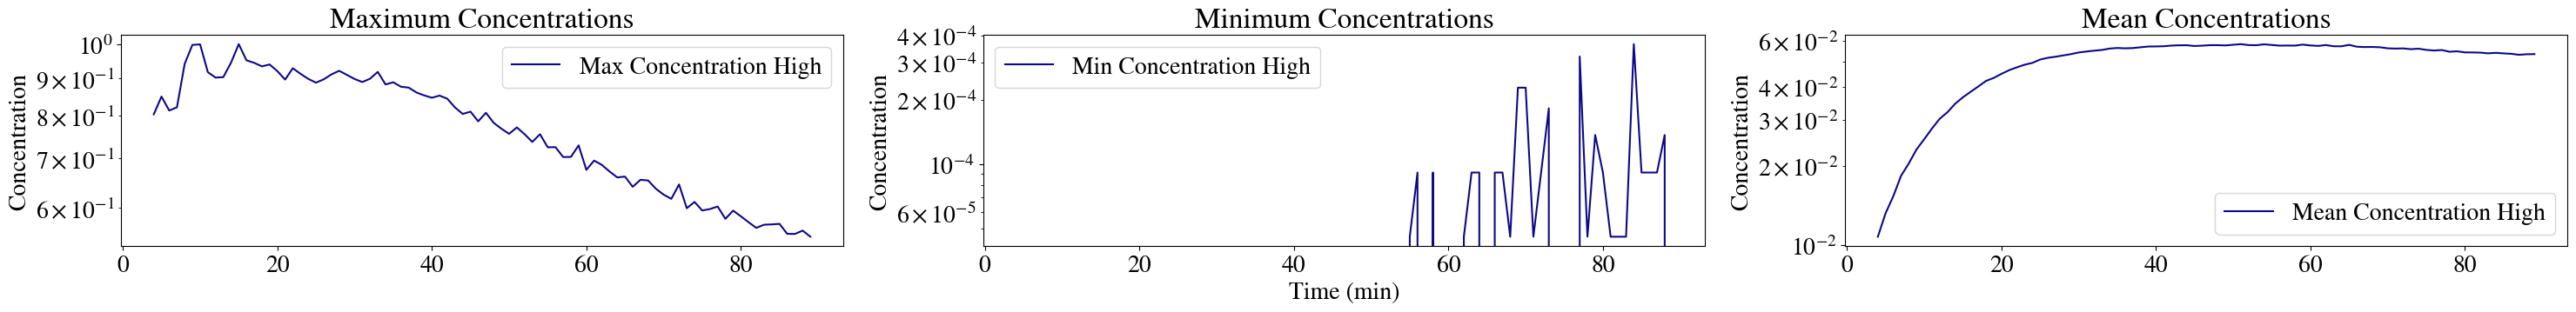

1.0


100%|██████████| 86/86 [00:05<00:00, 15.99it/s]


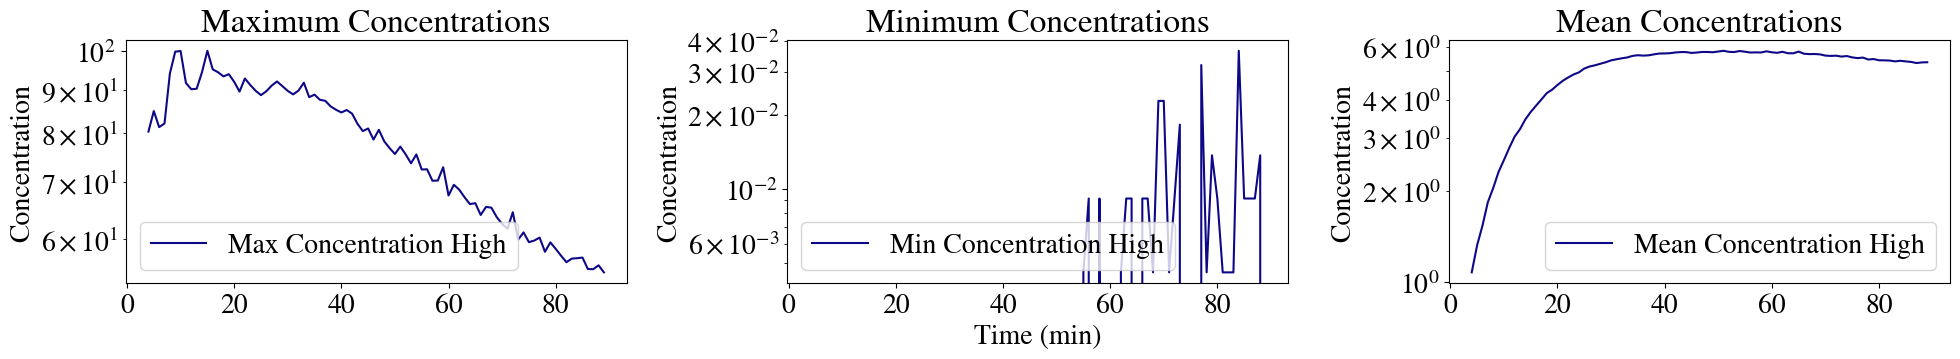

In [53]:
avoid_from=4
avoid_from_org=np.copy(avoid_from)
X_c_H=[]
X_res_H=[]
C_max_H=[]
C_min_H=[]
C_mean_H=[]

X_c_L=[]
X_res_L=[]
C_max_L=[]
C_min_L=[]
C_mean_L=[]

diff_time=[]
all_frames=[]
tol=0.05
for it in tqdm.tqdm(range(avoid_from,len(X_nnf))):
    all_frames.append(it)

    X_frame_H=X_nnf[it]

    time_H=X_frame_H[0,0]

    C_max_H.append(np.max(X_frame_H[:,4:5]))
    C_min_H.append(np.min(X_frame_H[:,4:5]))
    C_mean_H.append(np.mean(X_frame_H[:,4:5]))


# Creating the figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(30, 4))

# Plotting Max Concentrations for High and Low
axs[0].plot(all_frames, C_max_H, label='Max Concentration High')
axs[0].set_yscale('log')
axs[0].set_title('Maximum Concentrations')
axs[1].set_xlabel('Time (min)')
axs[0].set_ylabel('Concentration')
axs[0].legend()

# Plotting Min Concentrations for High and Low
axs[1].plot(all_frames, C_min_H, label='Min Concentration High')
axs[1].set_yscale('log')
axs[1].set_title('Minimum Concentrations')
axs[1].set_xlabel('Time (min)')
axs[1].set_ylabel('Concentration')
axs[1].legend()

# Plotting Mean Concentrations for High and Low
axs[2].plot(all_frames, C_mean_H, label='Mean Concentration High')
axs[2].set_yscale('log')
axs[2].set_title('Mean Concentrations')
axs[1].set_xlabel('Time (min)')
axs[2].set_ylabel('Concentration')
axs[2].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

min_H=np.min(C_min_H)
max_H=np.max(C_max_H)-min_H

max_all=max_H
print(max_all)
keep_c=max_H

X_c_H=[]
X_res_H=[]
C_max_H=[]
C_min_H=[]
C_mean_H=[]

X_c_L=[]
X_res_L=[]
C_max_L=[]
C_min_L=[]
C_mean_L=[]
X_nnf_bd=[]
all_frames=[]
for it in tqdm.tqdm(range(avoid_from,len(X_nnf))):
    all_frames.append(it)

    X_frame_H=X_nnf[it,:,:5]-min_H
    idx_keep0=np.argwhere(X_frame_H[:,4]<=keep_c).flatten()
    X_frame_H=X_frame_H[idx_keep0]*np.array([[1,1,1,1,100/keep_c]])

    C_max_H.append(np.max(X_frame_H[:,4:5]))
    C_min_H.append(np.min(X_frame_H[:,4:5]))
    C_mean_H.append(np.mean(X_frame_H[:,4:5]))

    idx_keep=np.argwhere(X_frame_H[:,4]>tol*np.mean(X_frame_H[:,4:5])).flatten()
    X_res_H.append(X_frame_H[idx_keep])
    X_c_H.append(X_frame_H)

    X_nnf_bd.append(X_frame_H)




# Creating the figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(20, 4))

# Plotting Max Concentrations for High and Low
axs[0].plot(all_frames, C_max_H, label='Max Concentration High')
axs[0].set_yscale('log')
axs[0].set_title('Maximum Concentrations')
axs[1].set_xlabel('Time (min)')
axs[0].set_ylabel('Concentration')
axs[0].legend()

# Plotting Min Concentrations for High and Low
axs[1].plot(all_frames, C_min_H, label='Min Concentration High')
axs[1].set_yscale('log')
axs[1].set_title('Minimum Concentrations')
axs[1].set_xlabel('Time (min)')
axs[1].set_ylabel('Concentration')
axs[1].legend()

# Plotting Mean Concentrations for High and Low
axs[2].plot(all_frames, C_mean_H, label='Mean Concentration High')
axs[2].set_yscale('log')
axs[2].set_title('Mean Concentrations')
axs[1].set_xlabel('Time (min)')
axs[2].set_ylabel('Concentration')
axs[2].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()



In [54]:
frames=X_c_H
avoid_from=0
if train_ratio<=0.5:
    skip_frames = int(1 / train_ratio)
    idx_all_frames = np.arange(avoid_from, len(frames))
    idx_Train = np.arange(avoid_from+1, len(frames) - 1, skip_frames)
    idx_Train = np.append([avoid_from], idx_Train)  # Add the first frame
    idx_Train = np.append(idx_Train, [len(frames) - 1])  # Add the last frame
    idx_Test = np.setdiff1d(idx_all_frames, idx_Train)
    print(f'Skipping:{skip_frames}')
    print(f'Training on frames:{idx_Train}')
    print(f'Testing on frames:{idx_Test}')
    print(f'Training on {len(idx_Train)/len(frames)}')
else:
    idx_all_frames =np.arange(avoid_from,len(frames))
    idx_Train=np.random.choice(len(frames)-avoid_from,int((len(frames)-avoid_from)*train_ratio),replace=False)+avoid_from
    idx_Train = np.append([avoid_from], idx_Train)  # Add the first frame
    idx_Train = np.append(idx_Train, [len(frames) - 1])  # Add the last frame
    idx_Train = np.unique(idx_Train)
    idx_Test =np.setdiff1d(idx_all_frames,idx_Train)
    print(f'There are not enough frames to skip')
    print(f'Training on frames:{np.sort(idx_Train)}')
    print(f'Testing on frames:{idx_Test}')
    print(f'Training on {len(idx_Train)/len(frames)}')
X_train=np.zeros((1,5))
for idx in tqdm.tqdm(idx_Train):
    X_train=np.vstack((X_train,X_c_H[idx]))
X_train_H=np.copy(X_train[1:])
X_test=np.zeros((1,5))
for idx in tqdm.tqdm(idx_Test):
    X_test=np.vstack((X_test,X_c_H[idx]))
X_test_H=np.copy(X_test[1:])

Skipping:2
Training on frames:[ 0  1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45
 47 49 51 53 55 57 59 61 63 65 67 69 71 73 75 77 79 81 83 85]
Testing on frames:[ 2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48
 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84]
Training on 0.5116279069767442


 23%|██▎       | 10/44 [00:00<00:00, 87.74it/s]

100%|██████████| 42/42 [00:01<00:00, 21.13it/s]


In [55]:
X_res_H=np.vstack(X_res_H)

X_train_H=np.vstack(X_train_H)
X_test_H=np.vstack(X_test_H)

num_points=150000
if len(X_test_H)<num_points:
    X_GT_H=np.copy(X_test_H)
else:   
    idx_Gt=np.random.choice(len(X_test_H),num_points,replace=False)
    X_GT_H=X_test_H[idx_Gt]

# Printing the shapes of the datasets for verification
print(f"Training set shape high: {X_train_H.shape}")
print(f"Test set shape high: {X_train_H.shape}")
print(f"Test Eval set shape high: {X_GT_H.shape}")
print(f"Residual set shape high: {X_res_H.shape}")

Training set shape high: (20426120, 5)
Test set shape high: (20426120, 5)
Test Eval set shape high: (150000, 5)
Residual set shape high: (37704323, 5)


In [56]:
dataset={}
dataset['GT']=X_GT_H

## Define Model

In [57]:
def u_PINN(params):
    # Neural Network
    fn={
        'P' :lambda x: pinn_fn(params['P'], jnp.array([0.0,x[1],x[2],x[3]]), M1_all['c'], M2_all['c'],activation_fn,norm_fn),
        'c' :lambda x: pinn_fn(params['c'], jnp.array([x[0],x[1],x[2],x[3]]), M1_all['c'], M2_all['c'],activation_fn,norm_fn),
        'c_std' :lambda x: pinn_fn(params['c_std'], jnp.array([x[0],x[1],x[2],x[3]]), M1_all['c'], M2_all['c'],activation_fn,norm_fn),
        'k' :lambda x: pinn_fn(params['k'], jnp.array([0.0,x[1],x[2],x[3]]), M1_all['k'], M2_all['k'],activation_fn,norm_fn),
        'D' :lambda x: pinn_fn(params['D'], jnp.array([0.0,x[1],x[2],x[3]]), M1_all['D'], M2_all['D'],activation_fn,norm_fn),
    }
    #Pretrained Models
    log_k= (
                 lambda x:-(lb_all['k']+ub_all['k']*jax.nn.sigmoid(fn['k'](x)[0])))
    k= (
                 lambda x: (jnp.exp(log_k(x)+off_set['k']))
                 )
    log_D= (
                 lambda x:-(lb_all['D']+ub_all['D']*jax.nn.sigmoid(fn['D'](x)[0]))
                 )
    D= (
                 lambda x: jnp.exp(log_D(x)+off_set['D'])
                 )
    #New Models
    p,c,c_std= (
                 lambda x: fn['P'](x)[0], 
                 lambda x: fn['c'](x)[0],
                 lambda x: 10*jax.nn.sigmoid(fn['c_std'](x)[0])+sigma_0,
                 )
   # derivatives
    def derivative_fn(f, x, idx):
        """Computes df/dx[idx] using forward mode AD."""
        perturbation = jnp.zeros_like(x)
        perturbation = perturbation.at[idx].set(1.0)
        primals, tangents = jvp(f, (x,), (perturbation,))
        return tangents

    p_x = lambda x: derivative_fn(p, x, 1)
    p_y = lambda x: derivative_fn(p, x, 2)
    p_z = lambda x: derivative_fn(p, x, 3)

    u = lambda x:-p_scale*k(x)*p_x(x)
    v = lambda x:-p_scale*k(x)*p_y(x)
    w = lambda x:-p_scale*k(x)*p_z(x)
    return u,v,w,p,c,D,k,c_std

u_model=u_PINN


In [58]:
def compute_prediction(X, funcs):
    result = jnp.zeros((X.shape[0], len(funcs)))
    for i, fn in enumerate(funcs):
        result = result.at[:, i].set(vmap(fn, (0))(X[:, :layers_ref[0]]).flatten())
    return result

# Load Trained Parameters

In [59]:
loaded_params = load_params_dict(result_path, dataset_name, layers, initialization,type='Final',Use_ResNet=Use_ResNet) 
print('Parameters loaded from file')

loss_path=result_path+f'{dataset_name}-_loss.npy'
losses=np.load(loss_path,allow_pickle=True)
log_loss=losses
params=loaded_params
print('Parameters Loaded from file')

100%|██████████| 1/1 [00:00<00:00, 40.62it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 29.58it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 45.61it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 56.24it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 30.71it/s]


Initializing:mlp parameters.
Parameters loaded from file
Parameters Loaded from file


## Training Metrics (Losses, errors, etc.)

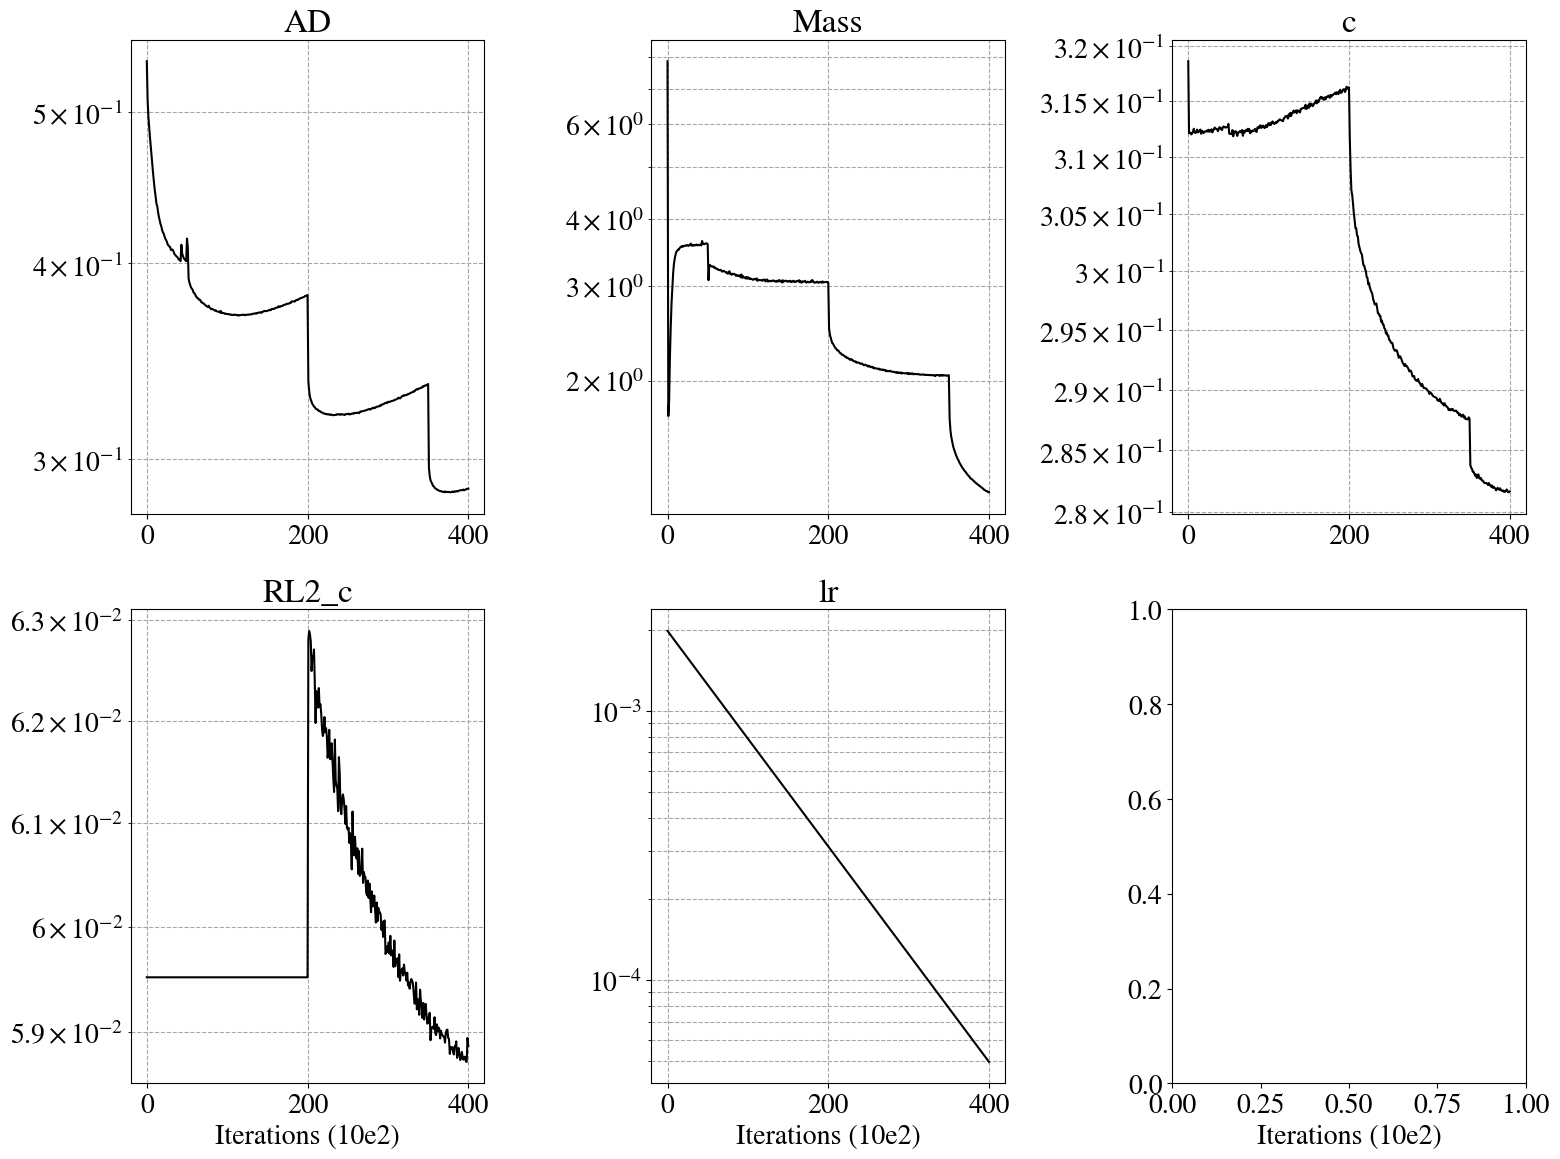

In [60]:
# Call the function
plot_losses_grid(log_loss)
plt.savefig(result_path + f'Losses.png')
plt.show()


### Validation error

In [61]:
u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
# Further computations for errors if any
u_pred  = vmap(u_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
v_pred  = vmap(v_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
w_pred  = vmap(w_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
p_pred  = vmap(p_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
c_pred  = vmap(c_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
velocity_magnitude = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)

RL2_c = relative_error2(c_pred, dataset['GT'][:,4:5])
print(f'Relative L2 errors for c:{RL2_c:.4e}')
u_max, u_min = np.max(u_pred), np.min(u_pred)
v_max, v_min = np.max(v_pred), np.min(v_pred)
w_max, w_min = np.max(w_pred), np.min(w_pred)
p_max, p_min = np.max(p_pred), np.min(p_pred)
c_max, c_min = np.max(c_pred), np.min(c_pred)
vmag_max, vmag_min= np.max(velocity_magnitude), np.min(velocity_magnitude)

Relative L2 errors for c:5.8873e-02


#### Non-Dimensional Units

In [62]:
#Arrays
T_star=X_nnf[:,:,0]
X_star=X_nnf[:,:,1]
Y_star=X_nnf[:,:,2]
Z_star=X_nnf[:,:,3]
C_star=X_nnf[:,:,4]

nu_e=7*10**(-7)
rho=993
h=0.00034 #Maximum length by 100
L_char=h
U_char=0.1#mm/min
D_char=2.4e-10*5#m2/s
U_char=U_char*(1/60)#\mum/s
T_char0=np.copy(T_char)
T_char=L_char/U_char
C_char=1/(100/keep_c)
mms=10**3
L_char=L_char*mms
U_char=U_char*mms
sigma_0=0.01

print(T_char,L_char,U_char,C_char,D_char)
rec_fact=np.array([[T_char,L_char,L_char,L_char,U_char,U_char,U_char,P_char,C_char]])
print(rec_fact)

0.20400000000000001 0.34 1.6666666666666667 0.01 1.2e-09
[[2.04000000e-01 3.40000000e-01 3.40000000e-01 3.40000000e-01
  1.66666667e+00 1.66666667e+00 1.66666667e+00 3.91736667e+01
  1.00000000e-02]]


### Concentration Results for all time-steps

In [63]:
Errors_c=[]
min_vals=[]
max_vals=[]
for t__frame_plot in tqdm.tqdm(range(avoid_from_org,len(T_star))):
    snap = np.array([t__frame_plot])
    t_test = T_star[snap,:].T
    x_test = X_star[snap,:].T
    y_test = Y_star[snap,:].T
    z_test = Z_star[snap,:].T
    c_test = C_star[snap,:].T
    X_test=np.hstack((t_test,x_test,y_test,z_test))
    # Further computations for errors if any
    u_pred  = vmap(u_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]
    v_pred  = vmap(v_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]
    w_pred  = vmap(w_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]
    p_pred  = vmap(p_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]
    c_pred  = vmap(c_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]*C_char
    velocity_magnitude = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)
    uvwpc_pred   = np.hstack((u_pred,v_pred,w_pred,p_pred,c_pred))
    u_pred, v_pred, w_pred, p_pred,c_pred,  =uvwpc_pred[:,0:1],uvwpc_pred[:,1:2],uvwpc_pred[:,2:3],uvwpc_pred[:,3:4],uvwpc_pred[:,4:5]
    error_c = relative_error(c_pred, c_test)
    data_frame=np.hstack((X_test,u_pred, v_pred, w_pred, p_pred,c_pred))
    data_frame=data_frame*rec_fact
    Errors_c.append(error_c)
    min_vals.append(np.min(uvwpc_pred,axis=0))
    max_vals.append(np.max(uvwpc_pred,axis=0))
print(f'Average RL2 for c over time:{np.mean(Errors_c)}')

  3%|▎         | 3/86 [00:02<01:07,  1.23it/s]

100%|██████████| 86/86 [01:06<00:00,  1.29it/s]

Average RL2 for c over time:0.0867384294549686


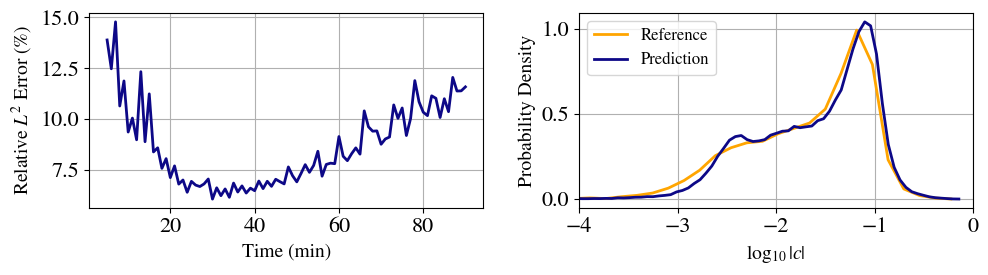

In [64]:
u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
c_pred  = np.abs(vmap(c_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None])*C_char+1e-16
c_test  =np.abs(dataset['GT'][:,4:5])*C_char+1e-16

mpl.rcParams['font.size'] = 16

def get_pdf(data, bins=300):
    hist, bins = np.histogram(data, bins=bins, density=True)
    return hist, bins

c_pred = np.log10(c_pred)
c_test = np.log10(c_test)

bins_pdf = 100  # number of bins to use for the histogram
pdf_pred, bins_pred = get_pdf(c_pred.flatten(), bins=bins_pdf)
pdf_test, bins_test = get_pdf(c_test.flatten(), bins=bins_pdf)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
ax1 = axes[1]
ax1.plot(bins_test[:-1], pdf_test, 'orange', label=rf'Reference', linewidth=2)
ax1.plot(bins_pred[:-1], pdf_pred, label=rf'Prediction', linewidth=2)
ax1.set_xlabel(rf'$\log_{{10}}|c|$', fontsize=14)
ax1.set_ylabel('Probability Density', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True)
ax1.set_xlim(-4, 0) 

ax2 = axes[0]
ax2.plot(5 + np.arange(len(Errors_c)), jnp.array(Errors_c) * 100, linestyle='-', linewidth=2)
ax2.set_xlabel('Time (min)', fontsize=14)
ax2.set_ylabel(rf'Relative $L^2$ Error (%)', fontsize=14)
ax2.grid(True)

plt.tight_layout()
plt.savefig('combined_concentration_plots.png', dpi=300)
plt.show()

In [65]:
t_list = [5, 30, 80]
variables_all = []

# Collect data for each time step
for t__frame_plot in t_list:
    snap = np.array([t__frame_plot])
    t_test = T_star[snap,:].T
    x_test = X_star[snap,:].T
    y_test = Y_star[snap,:].T
    z_test = Z_star[snap,:].T
    c_test = C_star[snap,:].T
    X_test = np.hstack((t_test, x_test, y_test, z_test))

    u_pred = vmap(u_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    v_pred = vmap(v_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    w_pred = vmap(w_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    p_pred = vmap(p_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*P_char
    c_pred = vmap(c_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char
    c_std_pred = vmap(c_std_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char

    uvwpc_pred = np.hstack((u_pred, v_pred, w_pred, p_pred, c_pred, c_std_pred))
    u_pred, v_pred, w_pred, p_pred, c_pred, c_std_pred = [uvwpc_pred[:, i:i+1] for i in range(6)]
    data_frame = np.hstack((X_test, u_pred, v_pred, w_pred, p_pred, c_pred, c_std_pred))

    idx_plot = np.random.choice(len(y_test), int(len(y_test)), replace=False)
    t_test, x_test, y_test, z_test, u_pred, v_pred, w_pred, p_pred, c_pred, c_std_pred = [np.copy(data_frame[idx_plot, i:i+1]) for i in range(10)]
    c_test = np.copy(c_test[idx_plot])

    x_midplane = np.median(x_test)
    y_midplane = np.median(y_test)
    z_midplane = np.median(z_test)

    tolerance = 0.5
    y_midplane_filter = np.abs(y_test - y_midplane) <= tolerance

    # Save the Y–Z midplane data for plotting
    x, y = x_test, z_test
    filter = y_midplane_filter
    variables_all.append({
        'time': t__frame_plot,
        'data': [c_pred,np.abs(c_test-c_pred), c_std_pred],
        'labels': [r'$c$', r'$|\hat{c}-c|$',r'$\sigma_c$', ],
        'filter': filter,
        'x': x,
        'y': y
    })


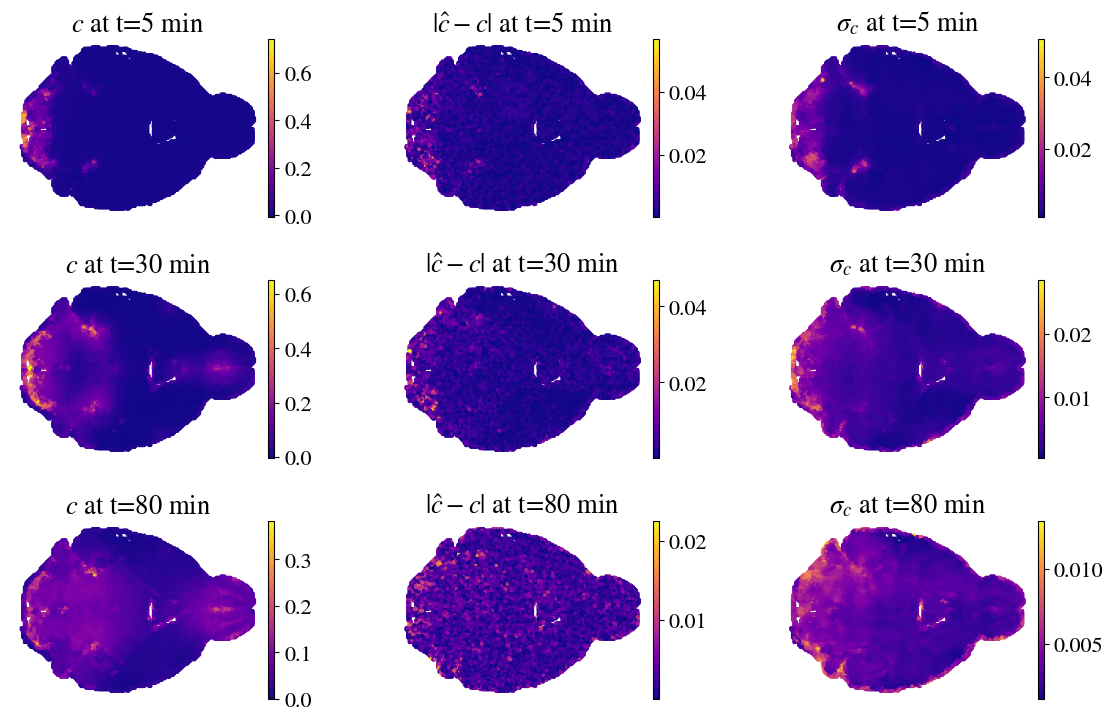

In [66]:
fig = plt.figure(figsize=(12, 2.5 * len(t_list)))
gs = gridspec.GridSpec(nrows=len(t_list), ncols=3, width_ratios=[1, 1, 1])

for i, entry in enumerate(variables_all):
    time = entry['time']
    vars_t = entry['data']
    labels = entry['labels']
    x, y = entry['x'], entry['y']
    filter = entry['filter']

    for j in range(3):
        ax = fig.add_subplot(gs[i, j])
        sc = ax.scatter(x[filter], y[filter], c=vars_t[j][filter], cmap=cmap, s=3)
        ax.set_title(f'{labels[j]} at t={time} min', pad=6)
        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

        # Independent colorbar for each subplot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="2.5%", pad=0.02)
        plt.colorbar(sc, cax=cax)

plt.tight_layout()
plt.savefig("Combined_timesteps.png", dpi=300)


### Results in XY plane

In [67]:

t_list = [5, 30, 80]
variables_all = []

for t__frame_plot in t_list:
    snap = np.array([t__frame_plot])
    t_test = T_star[snap,:].T
    x_test = X_star[snap,:].T
    y_test = Y_star[snap,:].T
    z_test = Z_star[snap,:].T
    c_test = C_star[snap,:].T
    X_test = np.hstack((t_test, x_test, y_test, z_test))

    u_pred = vmap(u_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    v_pred = vmap(v_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    w_pred = vmap(w_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    p_pred = vmap(p_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*P_char
    c_pred = vmap(c_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char*100
    c_std_pred = vmap(c_std_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char*100

    uvwpc_pred = np.hstack((u_pred, v_pred, w_pred, p_pred, c_pred, c_std_pred))
    u_pred, v_pred, w_pred, p_pred, c_pred, c_std_pred = [uvwpc_pred[:, i:i+1] for i in range(6)]
    data_frame = np.hstack((X_test, u_pred, v_pred, w_pred, p_pred, c_pred, c_std_pred))

    idx_plot = np.random.choice(len(y_test), int(len(y_test)), replace=False)
    t_test, x_test, y_test, z_test, u_pred, v_pred, w_pred, p_pred, c_pred, c_std_pred = [np.copy(data_frame[idx_plot, i:i+1]) for i in range(10)]
    c_test = np.copy(c_test[idx_plot])*100

    x_midplane = np.median(x_test)
    y_midplane = np.median(y_test)
    z_midplane = np.median(z_test)

    tolerance = 0.5
    y_midplane_filter = np.abs(y_test - y_midplane) <= tolerance
    z_midplane_filter = np.abs(z_test - z_midplane) <= tolerance

    # Save the Y–Z midplane data for plotting
    x, y = x_test, y_test
    filter = z_midplane_filter
    variables_all.append({
        'time': t__frame_plot,
        'data': [c_pred,np.abs(c_test-c_pred), c_std_pred,c_test],
        'labels': [r'$c$', r'$|\hat{c}-c|$',r'$\sigma_c$', ],
        'filter': filter,
        'x': x,
        'y': y,
    })

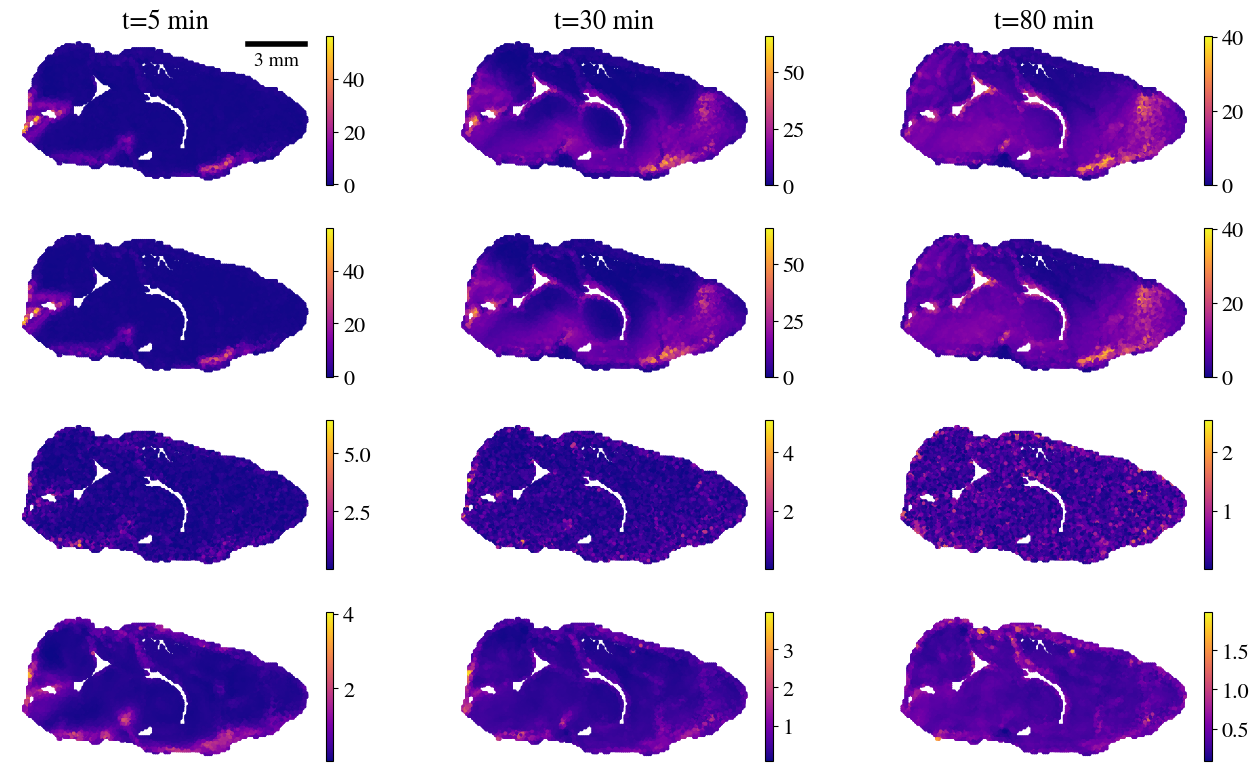

In [68]:
num_rows = 4 
num_cols = len(t_list) 

fig = plt.figure(figsize=(4.5 * num_cols, 2* num_rows))
gs = gridspec.GridSpec(nrows=num_rows, ncols=num_cols, figure=fig)
data_indices = [0, 3, 1, 2]

barscale_length = 3 
barscale_label = f'{barscale_length} mm' 

for j, entry in enumerate(variables_all):
    time = entry['time']
    x, y = entry['x'] * L_char, entry['y'] * L_char
    plot_filter = entry['filter']
    data_pred_idx = data_indices[0] 
    data_true_idx = data_indices[1] 
    data_pred = entry['data'][data_pred_idx]
    data_true = entry['data'][data_true_idx]
    filtered_pred = data_pred[plot_filter]
    filtered_true = data_true[plot_filter]
    combined_data = np.concatenate(
        (filtered_pred.flatten(), filtered_true.flatten())
        )

    common_vmin, common_vmax = None, None
    if combined_data.size > 0: 
        common_vmin = np.min(combined_data)
        common_vmax = np.max(combined_data)
    else:
        common_vmin, common_vmax = 0, 1 

    if common_vmin is not None and common_vmin == common_vmax:
         common_vmax += 1e-6


    for i in range(num_rows):
        ax = fig.add_subplot(gs[i, j]) 

        data_index = data_indices[i]
        data_to_plot = entry['data'][data_index]

        if (i == 0 or i == 1) and common_vmin is not None:
             sc = ax.scatter(x[plot_filter], y[plot_filter],
                             c=data_to_plot[plot_filter],
                             cmap=cmap, s=3,
                             vmin=common_vmin, vmax=common_vmax) 
        else:
             sc = ax.scatter(x[plot_filter], y[plot_filter],
                             c=data_to_plot[plot_filter],
                             cmap=cmap, s=3)
        if i == 0:
            ax.set_title(f't={time} min', pad=6)

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="2.5%", pad=0.05)
        plt.colorbar(sc, cax=cax)

        if i == 0 and j == 0:
            x_min_lim, x_max_lim = ax.get_xlim()
            y_min_lim, y_max_lim = ax.get_ylim()

            bar_y = y_min_lim + 0.95 * (y_max_lim - y_min_lim) # 95% up from bottom
            bar_x_end = x_min_lim + 0.95 * (x_max_lim - x_min_lim) # 95% from left
            bar_x_start = bar_x_end - barscale_length

            text_y = bar_y - 0.05 * (y_max_lim - y_min_lim) # Adjust vertical spacing
            text_x = bar_x_start + barscale_length / 2 # Center text horizontally

            ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], color='black', lw=4)
            ax.text(text_x, text_y, barscale_label,
                    ha='center', va='top', fontsize=14, color='black')


plt.tight_layout()
plt.savefig("Concentration_Results_XY.png", dpi=300)
plt.show() 

## All Fields

[-1.6884428e-02 -1.6884428e-02 -6.6730209e+01 -7.9603737e+01
 -4.1254456e+01 -8.6359245e+01]
[ 0.86178756  0.86178756 62.631756   46.82535    27.282      84.80002   ]


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:09<00:00,  9.40s/it]


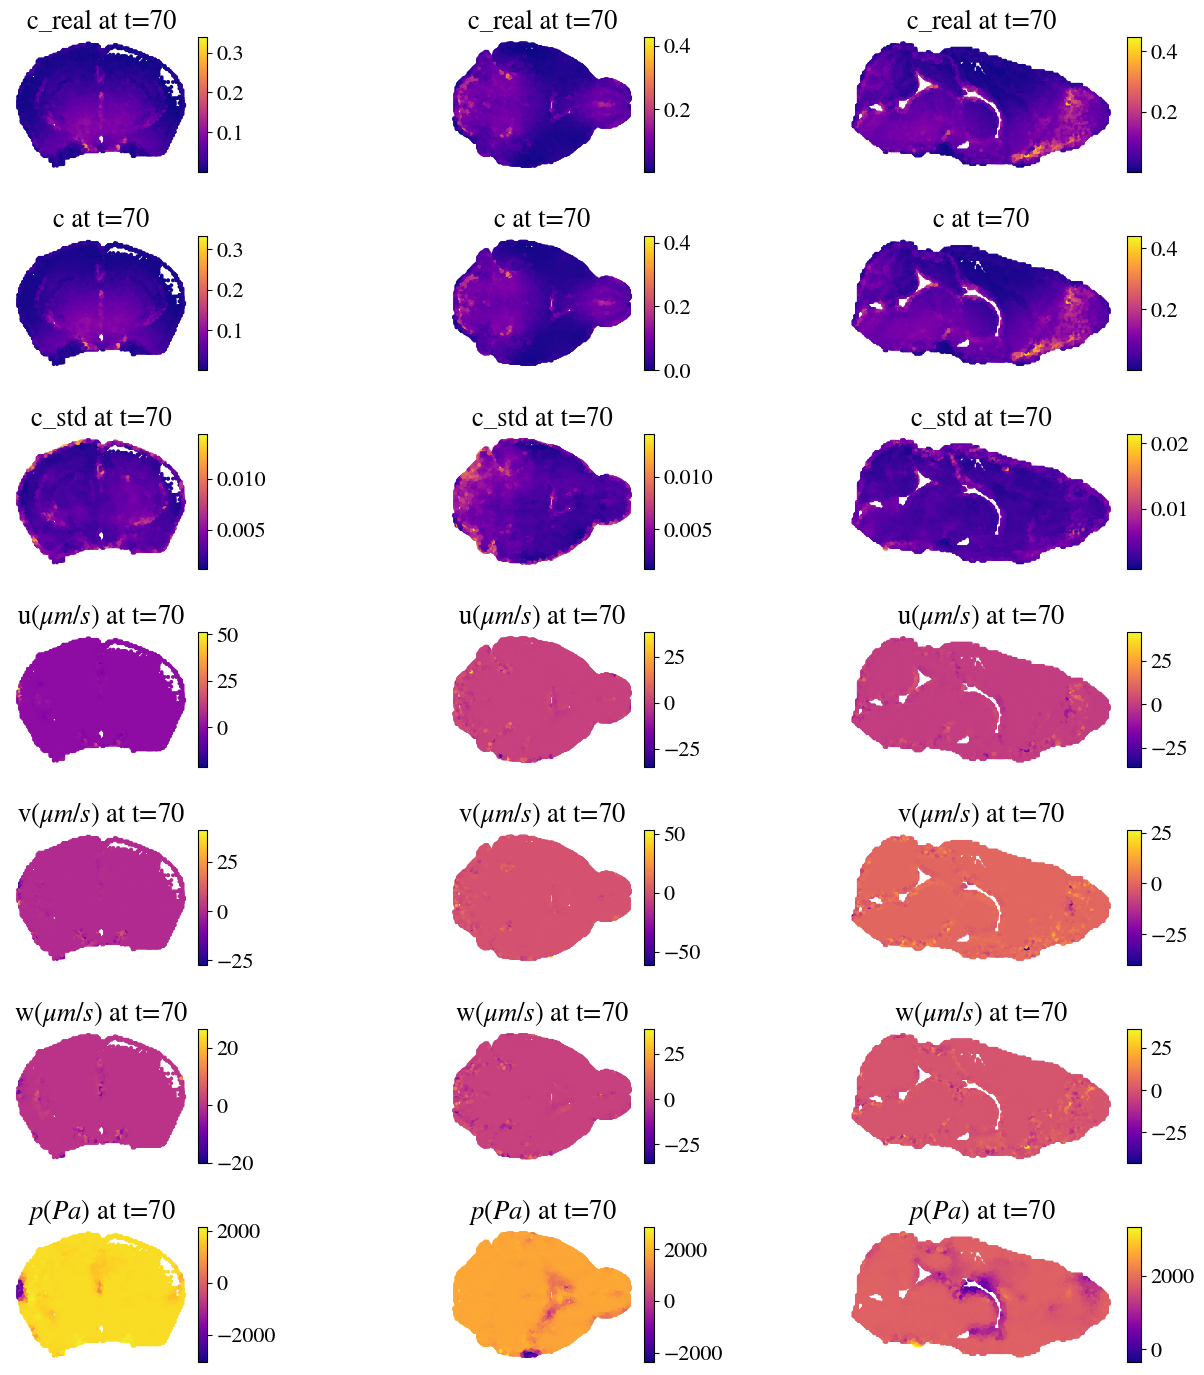

In [69]:
# Convert lists of min and max values to numpy arrays for easy indexing
min_vals_arr = np.array(min_vals)
min_vals_arr = np.hstack((min_vals_arr[:,4:5],min_vals_arr[:,4:5],min_vals_arr[:,:4]))
max_vals_arr = np.array(max_vals)
max_vals_arr = np.hstack((max_vals_arr[:,4:5],max_vals_arr[:,4:5],max_vals_arr[:,:4]))


# Compute global min and max for each variable across all frames
global_min = min_vals_arr.min(axis=0)
global_max = max_vals_arr.max(axis=0)
print(global_min)
print(global_max)
start=70
end=start+1
#end=len(T_star)
cmap = plt.get_cmap('plasma')

for t__frame_plot in tqdm.tqdm(range(start,end)):
    snap = np.array([t__frame_plot])
    t_test = T_star[snap,:].T
    x_test = X_star[snap,:].T
    y_test = Y_star[snap,:].T
    z_test = Z_star[snap,:].T
    c_test = C_star[snap,:].T
    X_test=np.hstack((t_test,x_test,y_test,z_test))
    # Further computations for errors if any
    u_pred  = vmap(u_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    v_pred  = vmap(v_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    w_pred  = vmap(w_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    p_pred  = vmap(p_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*P_char
    c_pred  = vmap(c_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char
    c_std_pred  = vmap(c_std_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char

    velocity_magnitude = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)
    uvwpc_pred   = np.hstack((u_pred,v_pred,w_pred,p_pred,c_pred,c_std_pred))
    u_pred, v_pred, w_pred, p_pred, c_pred,c_std_pred = uvwpc_pred[:, 0:1], uvwpc_pred[:, 1:2], uvwpc_pred[:, 2:3], uvwpc_pred[:, 3:4] , uvwpc_pred[:, 4:5], uvwpc_pred[:, 5:6]
    data_frame = np.hstack((X_test, u_pred, v_pred, w_pred, p_pred, c_pred,c_std_pred))

    idx_plot = np.random.choice(len(y_test), int(len(y_test)), replace=False)
    t_test, x_test, y_test, z_test, u_pred, v_pred, w_pred, p_pred, c_pred,c_std_pred = [np.copy(data_frame[idx_plot, i:i+1]) for i in range(10)]
    c_test = np.copy(c_test[idx_plot])

    x_midplane = np.median(x_test)
    y_midplane = np.median(y_test)
    z_midplane = np.median(z_test)

    tolerance = 0.5
    x_midplane_filter = np.abs(x_test - x_midplane) <= tolerance
    y_midplane_filter = np.abs(y_test - y_midplane) <= tolerance
    z_midplane_filter = np.abs(z_test - z_midplane) <= tolerance
    if end>start+1:
        variables = [c_test, c_pred]
        variable_names = ['c_real', 'c']
    variables = [c_test, c_pred,c_std_pred, u_pred, v_pred, w_pred, p_pred]
    variable_names = ['c_real', 'c','c_std' ,'u($\mu m/s$)', 'v($\mu m/s$)', 'w($\mu m/s$)', '$p(Pa)$']
    name_image = Video_path + f'time:{t__frame_plot / len(T_star):.4f}.png'

    fig = plt.figure(figsize=(14, 2 * len(variables)))

    for i, var in enumerate(variables):
        for j in range(3):
            ax = fig.add_subplot(len(variables), 3, i * 3 + j + 1)
            if j == 0:
                filter = x_midplane_filter
                x, y = z_test, y_test
                xlabel, ylabel = 'Y', 'Z'
            elif j == 1:
                filter = y_midplane_filter
                x, y = x_test, z_test
                xlabel, ylabel = 'X', 'Z'
            else:
                filter = z_midplane_filter
                x, y = x_test, y_test
                xlabel, ylabel = 'X', 'Y'

            #vmin, vmax = global_min[i], global_max[i]  # Use the global min/max values for each variable
            scatter = ax.scatter(x[filter], y[filter], c=var[filter], cmap=cmap, s=3)#], vmin=vmin, vmax=vmax)
            ax.set_title(f'{variable_names[i]} at t={t__frame_plot}')
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.axis('equal')
            ax.axis('off')

            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            plt.colorbar(scatter, cax=cax)

    plt.tight_layout()
    plt.savefig(name_image)
    if end>start+1:
        plt.close()


# Velocity Inference Results

In [70]:
dataset['Test_crop']=X_init_clean
u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
# Further computations for errors if any
u_pred  = vmap(u_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]*U_char
v_pred  = vmap(v_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]*U_char
w_pred  = vmap(w_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]*U_char
p_pred  = vmap(p_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]*p_scale*P_char
p_pred  =p_pred-p_pred.min()
c_pred  = vmap(c_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]

velocity_magnitude = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)

u_max, u_min = np.max(u_pred), np.min(u_pred)
v_max, v_min = np.max(v_pred), np.min(v_pred)
w_max, w_min = np.max(w_pred), np.min(w_pred)
p_max, p_min = np.max(p_pred), np.min(p_pred)
c_max, c_min = np.max(c_pred), np.min(c_pred)
vmag_max, vmag_min= np.max(velocity_magnitude), np.min(velocity_magnitude)



## IMPORTANT: Front Tracking Results

Here we use the front-tracking results for visual comparison however recall that these results are not the true velocity and ar nor physically correct. It is only for visualization purposes

In [71]:
## Front Tracking Results (Initialization Velocity) --> Recall that this is not the true velocity
x_test = dataset['Test_crop'][:,1:2]
y_test = dataset['Test_crop'][:,2:3]
z_test = dataset['Test_crop'][:,3:4]
u_test = dataset['Test_crop'][:,4:5]*U_char  
v_test = dataset['Test_crop'][:,5:6]*U_char  
w_test = dataset['Test_crop'][:,6:7]*U_char 


V_test = np.sqrt(u_test**2 + v_test**2 + w_test**2)
V_pred = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)

#### Plots

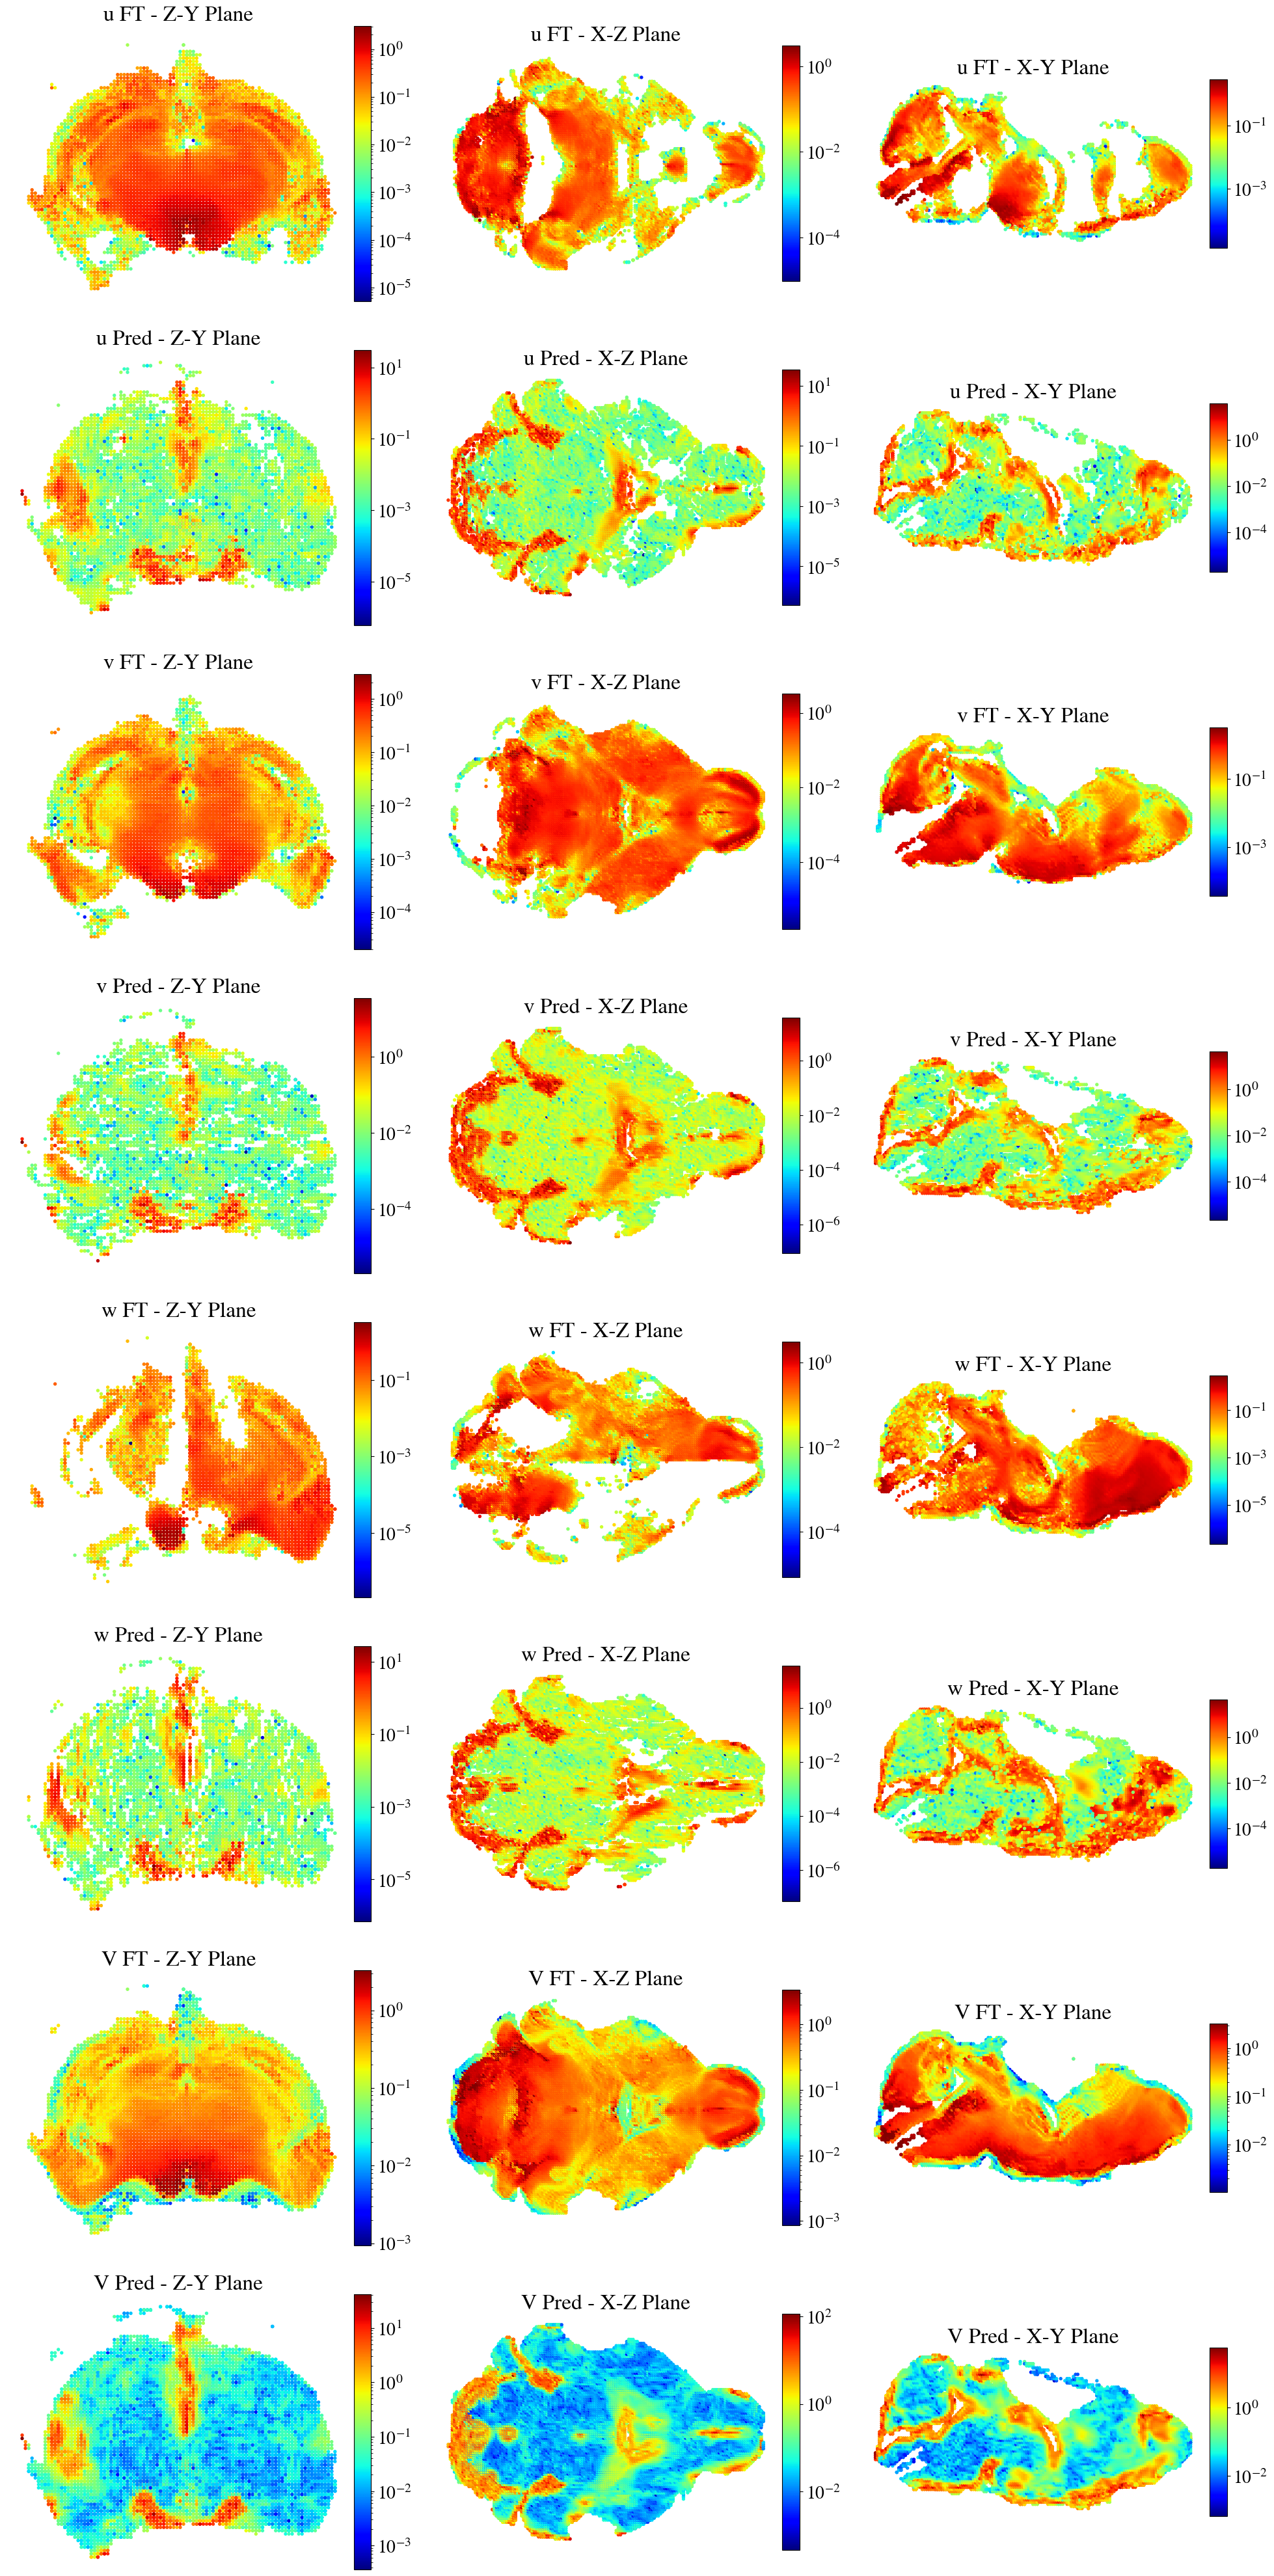

In [72]:
mpl.rcParams['font.size'] = 20
size_point=20

# Calculate midplane values
x_mid = np.median(x_test)
y_mid = np.median(y_test)
z_mid = np.median(z_test)

# Define tolerance for midplane filtering
tolerance = 1 # Adjust tolerance based on your data's scale

# Create filters for midplane slices
x_filter = np.abs(x_test - x_mid) <= tolerance
y_filter = np.abs(y_test - y_mid) <= tolerance
z_filter = np.abs(z_test - z_mid) <= tolerance

# Prepare the data for plotting
data_pairs = [
    (u_test, u_pred, 'u FT', 'u Pred'),
    (v_test, v_pred, 'v FT', 'v Pred'),
    (w_test, w_pred, 'w FT', 'w Pred'),
    (V_test, V_pred, 'V FT', 'V Pred')
]

# Define colormap
cmap = plt.get_cmap('jet')

# Start plotting
fig, axes = plt.subplots(nrows=8, ncols=3, figsize=(20, 40))

for i, (test_data, pred_data, test_label, pred_label) in enumerate(data_pairs):

    vmin = np.min(test_data[test_data > 0]) if np.any(test_data > 0) else 0.1
    vmax = np.max(test_data)

    if vmax <= vmin: 
        vmin = 0.1 
        vmax = 1.0 
        if np.any(test_data > 0): 
            min_positive = np.min(test_data[test_data > 0])
            max_val = np.max(test_data)
            if max_val > min_positive:
                vmin = min_positive
                vmax = max_val
            elif max_val > 0 : # if max_val is positive but equal to min_positive
                vmin = max_val / 10 if max_val / 10 > 0 else 0.01
                vmax = max_val


    log_norm = LogNorm(vmin=vmin, vmax=vmax)


    for j in range(3):
        if j == 0:  # 
            coords_x, coords_y = z_test, y_test
            xlabel, ylabel = 'Z', 'Y'
            current_filter = x_filter
        elif j == 1:  
            coords_x, coords_y = x_test, z_test
            xlabel, ylabel = 'X', 'Z'
            current_filter = y_filter
        else: 
            coords_x, coords_y = x_test, y_test
            xlabel, ylabel = 'X', 'Y'
            current_filter = z_filter

        ax_test = axes[i*2, j]
        ax_pred = axes[i*2+1, j]

        filtered_coords_x = coords_x[current_filter]
        filtered_coords_y = coords_y[current_filter]
        filtered_test_data = test_data[current_filter]
        filtered_pred_data = pred_data[current_filter]

        if filtered_test_data.size == 0:
            ax_test.set_title(f'{test_label} - {xlabel}-{ylabel} Plane (No Data)')
            ax_test.axis('off')
            ax_pred.set_title(f'{pred_label} - {xlabel}-{ylabel} Plane (No Data)')
            ax_pred.axis('off')
            continue

        current_vmin_test = np.min(filtered_test_data[filtered_test_data > 0]) if np.any(filtered_test_data > 0) else vmin
        current_vmax_test = np.max(filtered_test_data) if np.any(filtered_test_data) else vmax
        if current_vmax_test <= current_vmin_test :
             current_vmin_test = vmin 
             current_vmax_test = vmax

        current_log_norm_test = LogNorm(vmin=max(current_vmin_test, 1e-9), vmax=current_vmax_test) 


        current_vmin_pred = np.min(filtered_pred_data[filtered_pred_data > 0]) if np.any(filtered_pred_data > 0) else vmin
        current_vmax_pred = np.max(filtered_pred_data) if np.any(filtered_pred_data) else vmax
        if current_vmax_pred <= current_vmin_pred:
            current_vmin_pred = vmin
            current_vmax_pred = vmax

        current_log_norm_pred = LogNorm(vmin=max(current_vmin_pred, 1e-9), vmax=current_vmax_pred) 


        # Plot test data
        sc_test = ax_test.scatter(filtered_coords_x, filtered_coords_y, c=filtered_test_data, cmap=cmap, norm=current_log_norm_test,s=8)
        ax_test.set_title(f'{test_label} - {xlabel}-{ylabel} Plane')
        ax_test.set_xlabel(xlabel)
        ax_test.set_ylabel(ylabel)
        ax_test.axis('equal')
        ax_test.axis('off')
        divider = make_axes_locatable(ax_test)
        cax_test = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(sc_test, cax=cax_test)

        # If you want prediction to have its own log scale based on its own data range:
        sc_pred = ax_pred.scatter(filtered_coords_x, filtered_coords_y, c=filtered_pred_data, cmap=cmap, norm=current_log_norm_pred,s=8)

        ax_pred.set_title(f'{pred_label} - {xlabel}-{ylabel} Plane')
        ax_pred.set_xlabel(xlabel)
        ax_pred.set_ylabel(ylabel)
        ax_pred.axis('equal')
        ax_pred.axis('off')
        divider = make_axes_locatable(ax_pred)
        cax_pred = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(sc_pred, cax=cax_pred)


plt.tight_layout()
plt.savefig('Front_Tracking_vs_MR_AIV_velocities.png')
plt.show()

## Inferred Peremability

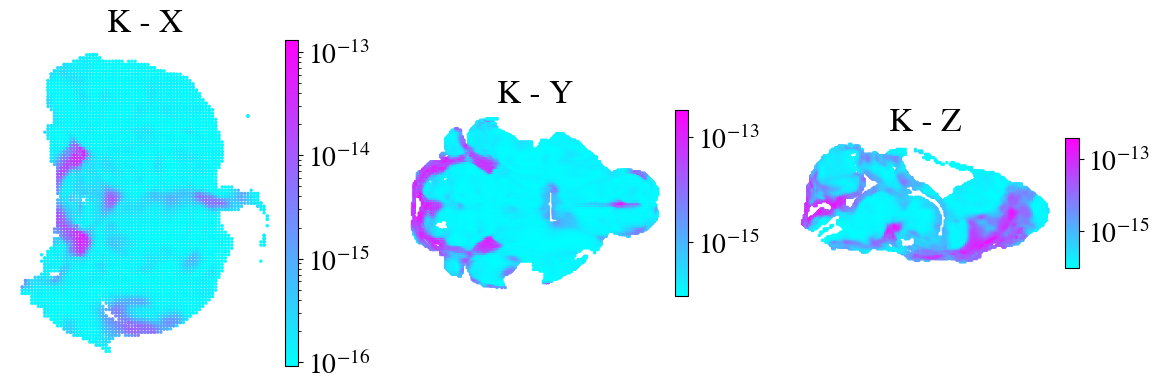

In [73]:
key='Permeability'
Dataset2={}
Dataset2['Permeability']=X_init_clean

K_pred  = vmap(k_fx, (0))(Dataset2[key][:,0:layers_ref[0]]) * k_char

if K_pred.ndim > 1 and K_pred.shape[1] == 1:
    K_pred = K_pred.flatten()

t,x, y, z_coords = Dataset2[key][:,0], Dataset2[key][:,1], Dataset2[key][:,2], Dataset2[key][:,3]

x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z_coords)

tolerance = 0.3 

x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z_coords - z_midplane) <= tolerance

variables_to_plot = [K_pred] 
variable_names = ['K']

cmap = plt.get_cmap('cool') 

# Visualization
for i, var_data in enumerate(variables_to_plot):
    fig = plt.figure(figsize=(12, 8)) 

    for j in range(3): 
        ax = fig.add_subplot(1, 3, j + 1)
        
        filter_mask = None
        scatter_x_plot, scatter_y_plot = None, None 

        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x_plot, scatter_y_plot = y[filter_mask], z_coords[filter_mask]
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x_plot, scatter_y_plot = x[filter_mask], z_coords[filter_mask]
        else:  
            filter_mask = z_midplane_filter
            scatter_x_plot, scatter_y_plot = x[filter_mask], y[filter_mask]

        color_data_slice = var_data[filter_mask] 
        
        if scatter_x_plot.size == 0 or color_data_slice.size == 0:

            ax.set_title(f'{variable_names[i]} - {["X", "Y", "Z"][j]} Plane (No data)')
            ax.axis('off')
            continue

        norm_for_plot = None
        title_suffix = "" 
        positive_color_data = color_data_slice[color_data_slice > 0]
        if positive_color_data.size > 0:
            vmin_log = np.min(positive_color_data)
            vmax_log = np.max(color_data_slice)

            if vmin_log >= vmax_log: 
                if vmax_log > 0: vmin_log = max(1e-9, vmax_log / 100.0) 
                else: 
                    vmin_log = 1e-9
                    vmax_log = 1.0
                if vmin_log >= vmax_log: vmax_log = vmin_log * 10 

            if vmin_log > 0 and vmax_log > vmin_log:
                 norm_for_plot = LogNorm(vmin=vmin_log, vmax=vmax_log)
            else:
                title_suffix = "\n(LogScale not applied; invalid range)"
        else:
            title_suffix = "\n(LogScale not applied; no positive data)"
        
        scatter = ax.scatter(scatter_x_plot, scatter_y_plot, c=color_data_slice, cmap=cmap, s=2, norm=norm_for_plot)
        
        ax.set_title(f'{variable_names[i]} - {["X", "Y", "Z"][j]}{title_suffix}')
        
        ax.axis('equal')
        ax.axis('off')

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        
        plt.colorbar(scatter, cax=cax)

plt.tight_layout()
plt.savefig('Learned_permeability_logscale.png') 
plt.show()